Evaluating MobileNetV2...


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step
Evaluating ResNet50...


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 400ms/step
Evaluating EfficientNetB0...


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 292ms/step


c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


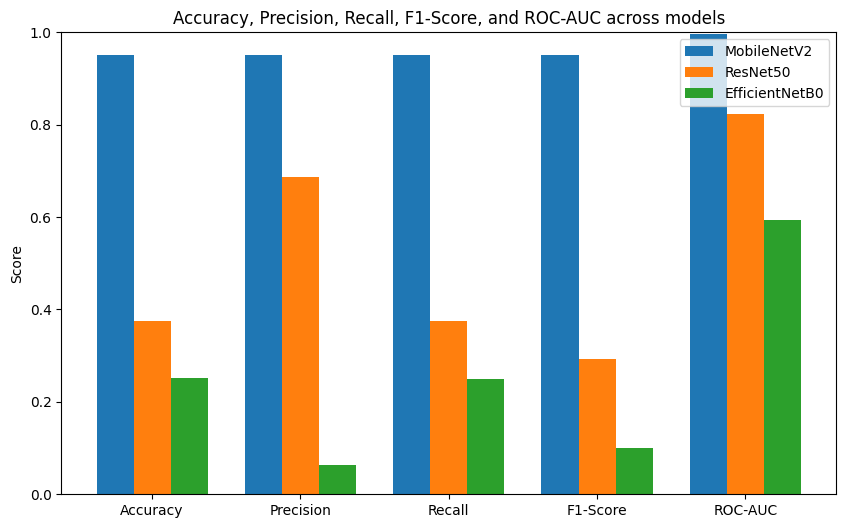

In [ ]:
#Comparison
import os
import h5py
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

# Paths
PROJECT_ROOT  = os.path.dirname(os.getcwd())   # step up from notebooks/
ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, "artifacts")
h5_path       = os.path.join(ARTIFACTS_DIR, "wildlife_data.h5")

# Load test set
with h5py.File(h5_path, "r") as f:
    X_test = f["X_test"][:]
    y_test = f["y_test"][:]

y_true = np.argmax(y_test, axis=1)

# Models to evaluate
models = {
    "MobileNetV2": "MobileNetV2_fine_tuned.h5",
    "ResNet50": "ResNet50_fine_tuned.h5",
    "EfficientNetB0": "EfficientNetB0_fine_tuned.h5"
}

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
results = {}

for name, filename in models.items():
    model_path = os.path.join(ARTIFACTS_DIR, filename)
    print(f"Evaluating {name}...")
    model = tf.keras.models.load_model(model_path)

    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")
    roc_auc = roc_auc_score(y_true, y_pred_proba, multi_class="ovr")

    results[name] = [acc, prec, rec, f1, roc_auc]

# Plot grouped bar chart
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))
for i, (name, scores) in enumerate(results.items()):
    ax.bar(x + i*width, scores, width, label=name)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Accuracy, Precision, Recall, F1-Score, and ROC-AUC across models")
ax.legend()
plt.ylim(0,1)
plt.show()



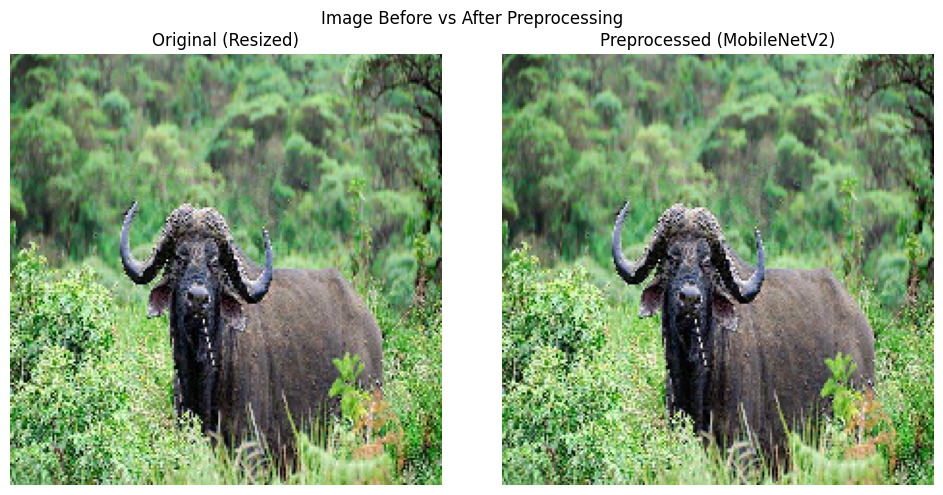

Original image stats:
  Min=0.0, Max=255.0, Mean=118.71
Preprocessed image stats:
  Min=-1.0, Max=1.0, Mean=-0.07


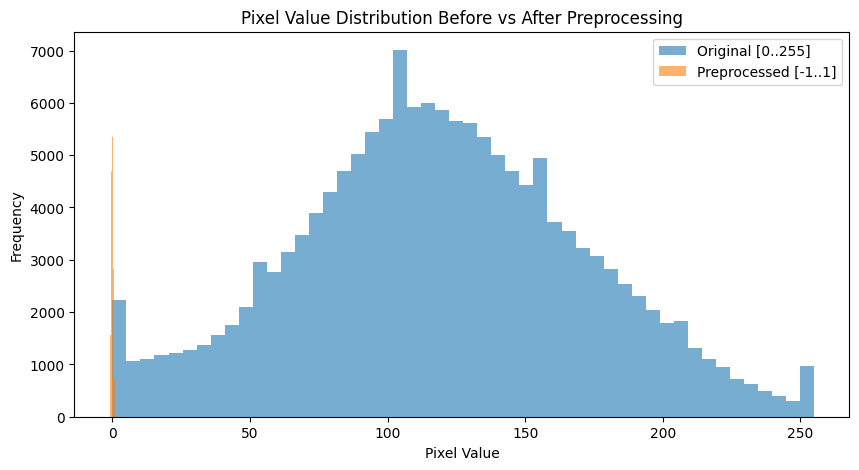

In [5]:
# One-image preprocessing demo for MobileNetV2
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Inline version of your prepare_data.py function
def preprocess_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = tf.expand_dims(img_array, axis=0)
    return img_array

# Pick one image from your dataset
img_path = "../data/Image_Dataset/1 (1).jpg"   # adjust path if needed

# Original resized image
original = tf.keras.utils.load_img(img_path, target_size=(224,224))
original_array = tf.keras.utils.img_to_array(original)

# Preprocessed (convert to numpy for stats)
preprocessed = preprocess_image(img_path)[0].numpy()

# --- Side-by-side image comparison ---
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(original_array.astype("uint8"))
axes[0].set_title("Original (Resized)")
axes[0].axis("off")

axes[1].imshow((preprocessed + 1) / 2)  # rescale back to [0,1] for display
axes[1].set_title("Preprocessed (MobileNetV2)")
axes[1].axis("off")

plt.suptitle("Image Before vs After Preprocessing")
plt.tight_layout()
plt.show()

# --- Pixel statistics ---
print("Original image stats:")
print(f"  Min={original_array.min()}, Max={original_array.max()}, Mean={original_array.mean():.2f}")

print("Preprocessed image stats:")
print(f"  Min={preprocessed.min()}, Max={preprocessed.max()}, Mean={preprocessed.mean():.2f}")

# --- Histogram comparison ---
plt.figure(figsize=(10,5))
plt.hist(original_array.flatten(), bins=50, alpha=0.6, label="Original [0..255]")
plt.hist(preprocessed.flatten(), bins=50, alpha=0.6, label="Preprocessed [-1..1]")
plt.legend()
plt.title("Pixel Value Distribution Before vs After Preprocessing")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()
